In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
dane = pd.read_csv('housing_cleaned.csv')

In [3]:
dane.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity,...,price_to_monthly_income_ratio,total_rooms_log,total_bedrooms_log,population_log,households_log,median_income_log,population_per_household_log,rooms_per_household_log,bedrooms_per_person_log,price_to_monthly_income_ratio_log
0,-122.23,37.88,41.0,880,129,322,126,8.3252,45.26,NEAR BAY,...,5.44,6.779922,4.859812,5.774552,4.836282,2.119287,0.940007,1.943049,0.336472,1.693779
1,-122.22,37.86,21.0,7099,1106,2401,1138,8.3014,35.85,NEAR BAY,...,4.32,8.867709,7.008505,7.783641,7.037028,2.116424,0.746688,1.830980,0.378436,1.463255
2,-122.24,37.85,52.0,1467,190,496,177,7.2574,35.21,NEAR BAY,...,4.85,7.290975,5.247024,6.206576,5.176150,1.982022,1.029619,2.115050,0.322083,1.578979
3,-122.25,37.85,52.0,1274,235,558,219,5.6431,34.13,NEAR BAY,...,6.05,7.149917,5.459586,6.324359,5.389072,1.730434,0.936093,1.761300,0.350657,1.800058
4,-122.25,37.85,52.0,1627,280,565,259,3.8462,34.22,NEAR BAY,...,8.90,7.394493,5.634790,6.336826,5.556828,1.347086,0.779325,1.837370,0.405465,2.186051


In [4]:
sns.set_theme(style="whitegrid")

In [5]:
dane['ocean_proximity'] = dane['ocean_proximity'].replace({
    '<1H OCEAN': '<1H do oceanu',
    'INLAND': 'W głębi lądu',
    'NEAR BAY': 'Blisko zatoki',
    'NEAR OCEAN': 'Blisko oceanu'
})

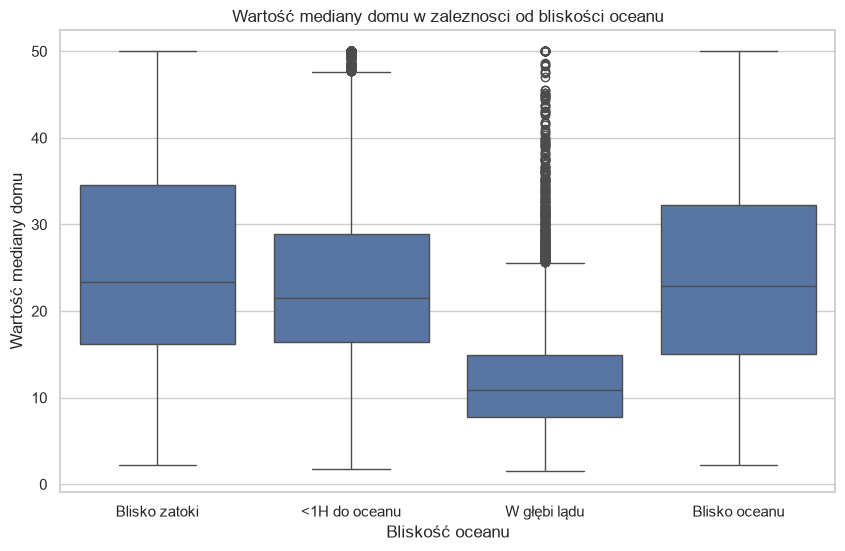

In [6]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='ocean_proximity', y='median_house_value', data=dane)
plt.title('Wartość mediany domu w zaleznosci od bliskości oceanu')
plt.xlabel('Bliskość oceanu')
plt.ylabel('Wartość mediany domu')
plt.show()

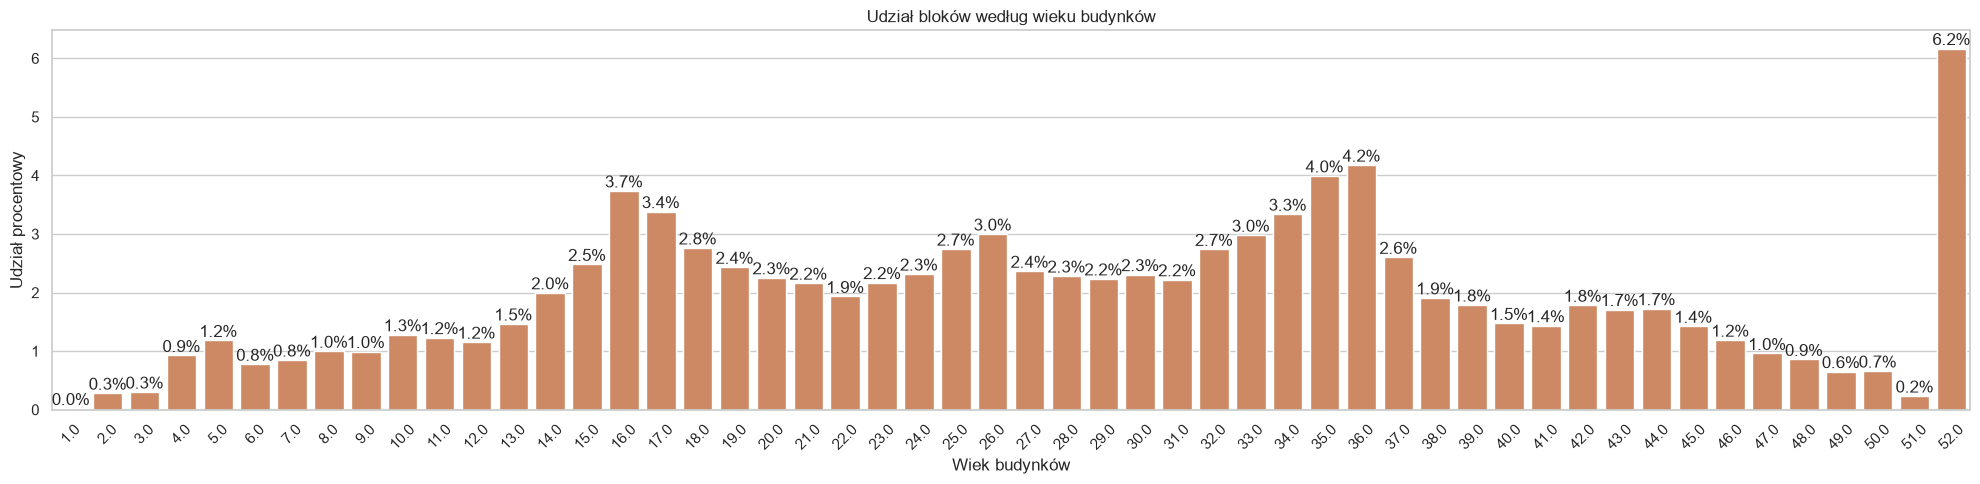

In [9]:
udzial = dane['housing_median_age'].value_counts(normalize=True) * 100
plt.figure(figsize=(20, 5))
ax = sns.barplot(x=udzial.index, y=udzial.values)
ax.bar_label(ax.containers[0], fmt='%.1f%%')
sns.barplot(x=udzial.index, y=udzial.values)
plt.title('Udział bloków według wieku budynków')
plt.xlabel('Wiek budynków')
plt.ylabel('Udział procentowy')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

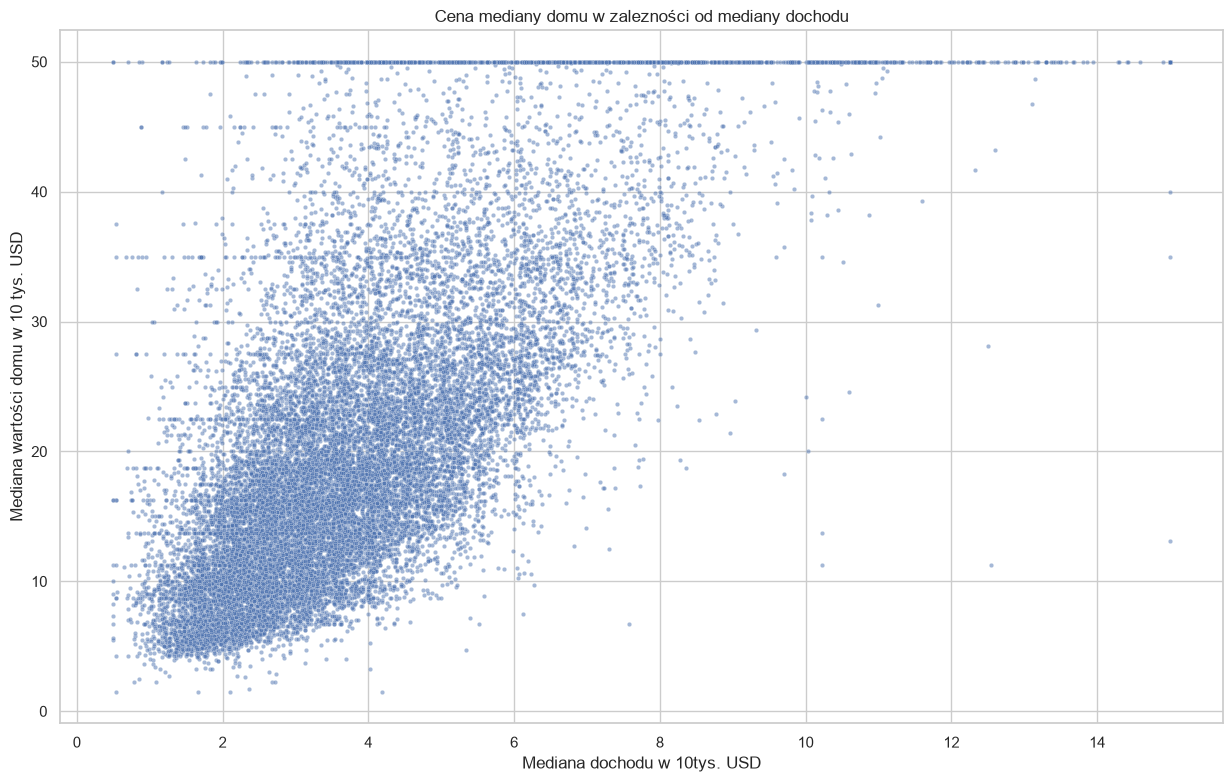

In [22]:
plt.figure(figsize=(15,9))
sns.scatterplot(x='median_income', y='median_house_value', data=dane, alpha=0.50, s=10)
plt.title('Cena mediany domu w zalezności od mediany dochodu')
plt.xlabel('Mediana dochodu w 10tys. USD')
plt.ylabel('Mediana wartości domu w 10 tys. USD')
plt.show()

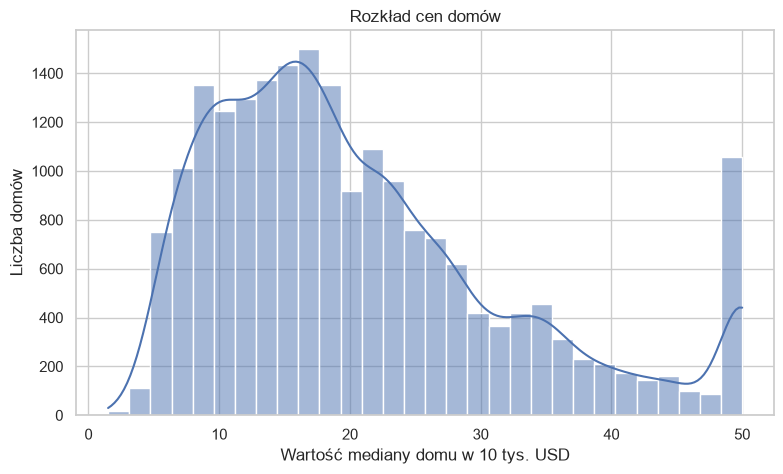

In [25]:
plt.figure(figsize=(9, 5))
sns.histplot(data=dane, x='median_house_value', bins=30, kde=True)
plt.title('Rozkład cen domów')
plt.xlabel('Wartość mediany domu w 10 tys. USD')
plt.ylabel('Liczba domów')
plt.show()

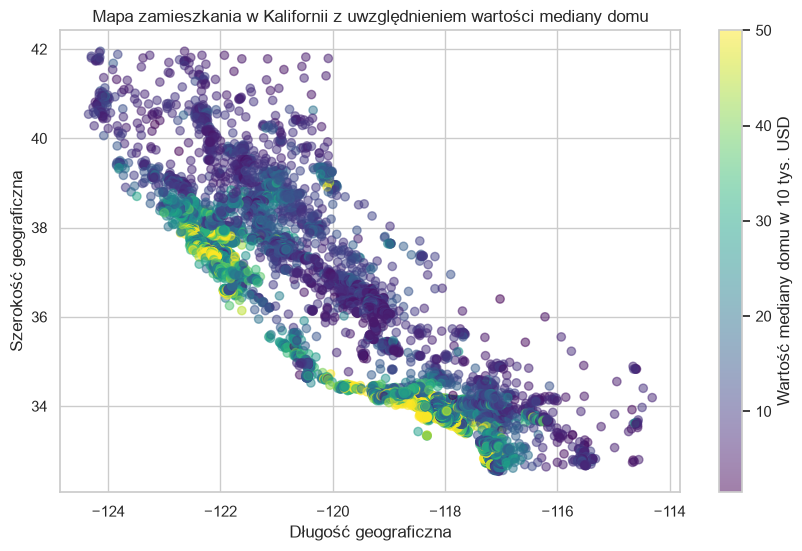

In [24]:
plt.figure(figsize=(10, 6))
sc = plt.scatter(dane['longitude'], dane['latitude'], c=dane['median_house_value'], cmap='viridis', alpha=0.5)
plt.colorbar(sc, label='Wartość mediany domu w 10 tys. USD')
plt.title('Mapa zamieszkania w Kalifornii z uwzględnieniem wartości mediany domu')
plt.xlabel('Długość geograficzna')
plt.ylabel('Szerokość geograficzna')
plt.show()